<a href="https://colab.research.google.com/github/matiasmorgan1/Master-s-by-Research/blob/main/Howat_Terminus_Positions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import numpy as np
import seaborn as sns
import os

# Mount Google Drive
drive.mount('/content/drive')

# Paths
data_folder = '/content/drive/MyDrive/MRes_IceMarginalChange/Howat_Margins/'
plot_folder = os.path.join(data_folder, 'Plots')
os.makedirs(plot_folder, exist_ok=True)


# Glacier filenames
file_map = {
    "002_Anoritup": "frontposition_002_anoritup_kangerdlua.txt",
    "007_Bernstorff": "frontposition_007_bernstorf_mid.txt",
    "008_Sleipner": "frontposition_008_bernstorf_north.txt",
    "028_Fenris": "frontposition_028_fenris.txt",
    "031_UmiivikN": "frontposition_031_fridtjof.txt",
    "035_Graulv": "frontposition_035_gyldenslove.txt",
    "036_UmiivikS": "frontposition_036_gyldenslove_south.txt",
    "040_Heimdal": "frontposition_040_heimdal.txt",
    "041_Helheim": "frontposition_041_helheim.txt",
    "046_IkertivaqS": "frontposition_046_ikertivaq_2_east.txt",
    "047_IkertivaqN": "frontposition_047_ikertivaq_1_west.txt",
    "059_HerlufTrolle": "frontposition_059_kap_herlut_trolle.txt",
    "060_Njordenskjold": "frontposition_060_kap_njordenskjold.txt",
    "061_KogeC": "frontposition_061_koge_bugt_mid.txt",
    "062_KogeN": "frontposition_062_koge_bugt_north.txt",
    "063_KogeS": "frontposition_063_koge_bugt_south.txt",
    "073_Midgard": "frontposition_073_midgard.txt",
    "075_MogensC": "frontposition_075_mogens_mid.txt",
    "076_ModenN": "frontposition_076_mogens_north.txt",
    "077_MogensS": "frontposition_077_mogens_south.txt",
    "094_PuisortoqN": "frontposition_094_puisortuq_north.txt",
    "100_Rimfaxe": "frontposition_100_sehested.txt",
    "103_Skinfaxe": "frontposition_103_skinefaxe.txt",
    "115_Tingmiarmuit": "frontposition_115_tingmjarmiut.txt"
}


name_map = {
    "002_Anoritup": "Anoritup",
    "007_Bernstorff": "Bernstorff",
    "008_Sleipner": "Sleipner",
    "028_Fenris": "Fenris",
    "031_UmiivikN": "UmiivikN",
    "035_Graulv": "Graulv",
    "036_UmiivikS": "UmiivikS",
    "040_Heimdal": "Heimdal",
    "041_Helheim": "Helheim",
    "046_IkertivaqS": "IkertivaqS",
    "047_IkertivaqN": "IkertivaqN",
    "059_HerlufTrolle": "HerlufTrolle",
    "060_Njordenskjold": "Njordenskjold",
    "061_KogeC": "KogeC",
    "062_KogeN": "KogeN",
    "063_KogeS": "KogeS",
    "073_Midgard": "Midgard",
    "075_MogensC": "MogensC",
    "076_ModenN": "ModenN",
    "077_MogensS": "MogensS",
    "094_PuisortoqN": "PuisortoqN",
    "100_Rimfaxe": "Rimfaxe",
    "103_Skinfaxe": "Skinfaxe",
    "115_Tingmiarmuit": "Tingmiarmuit"
}

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


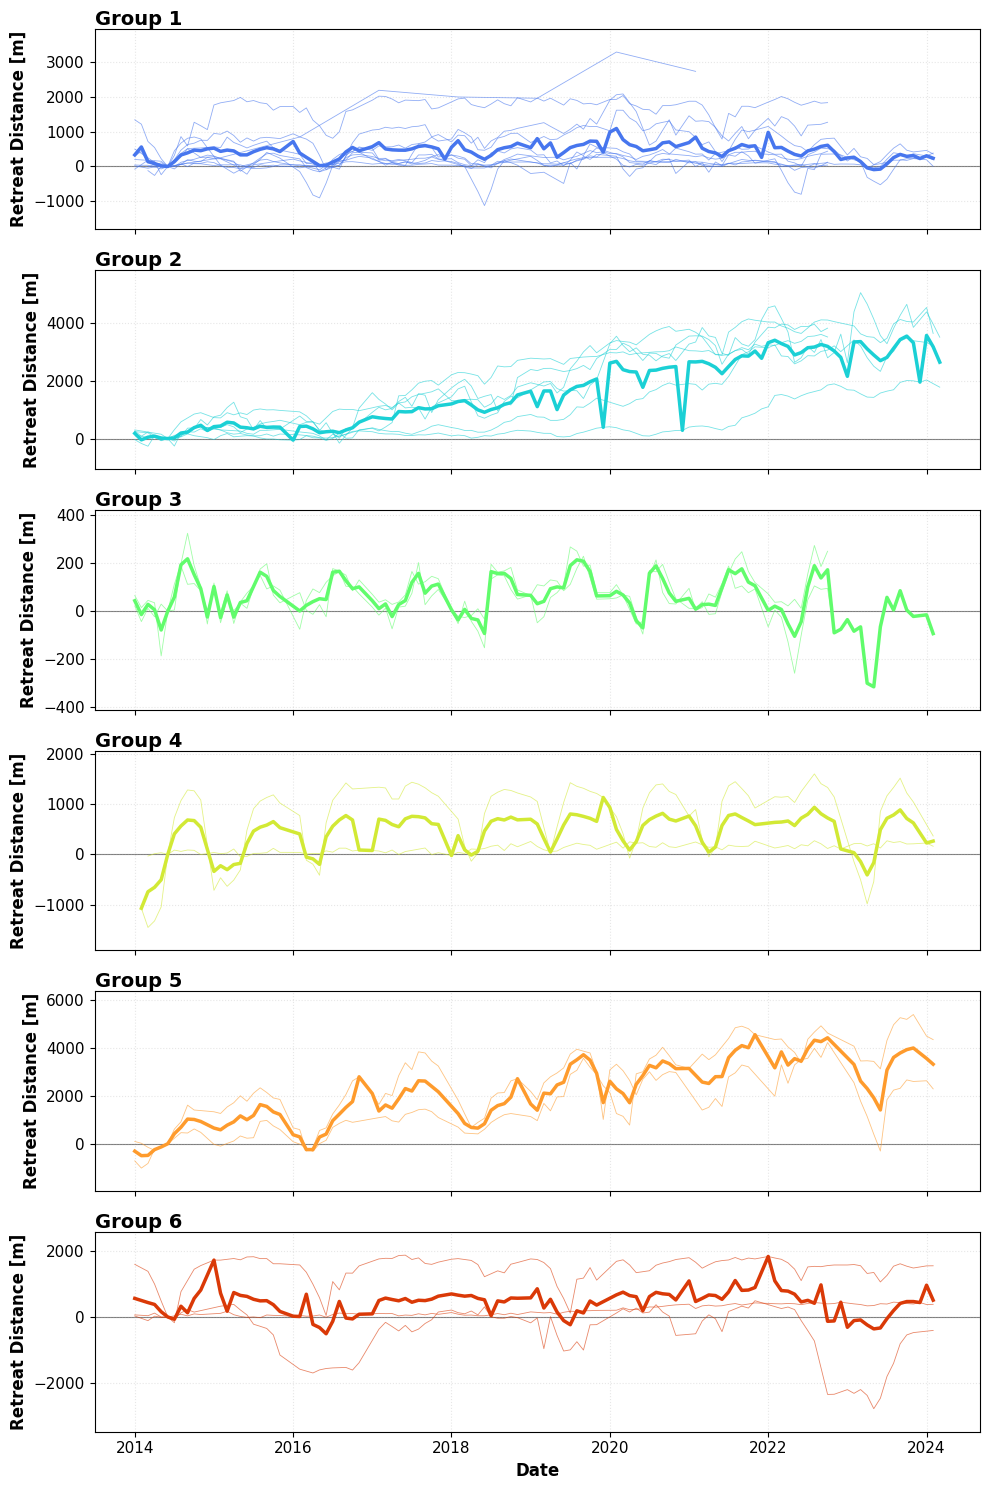

In [ ]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import drive

# 1. Mount Google Drive
drive.mount("/content/drive")

file_path = "/content/drive/My Drive/Spreadsheets/Monthly_Front_Retreat_2014_2024_Raw.xlsx"

if not os.path.exists(file_path):
  print(f"File not found at {file_path}. Please check the path.")
else:
  # 2. Load the data
  df_raw = pd.read_excel(file_path, index_col=0)

  # 3. Define Cluster Dictionary & Styling (6 Clusters)
  cluster_dict = {
    # Cluster 1 (10 glaciers)
    232: 1,
    245: 1,
    296: 1,
    266: 1,
    284: 1,  # (286 omitted in favor of 284)
    293: 1,
    304: 1,
    300: 1,
    335: 1,
    310: 1,
    # Cluster 2 (6 glaciers)
    303: 2,
    320: 2,  # (323 omitted in favor of 320)
    302: 2,
    330: 2,
    281: 2,
    258: 2,
    # Cluster 3 (2 glaciers)
    298: 3,
    297: 3,
    # Cluster 4 (2 glaciers)
    233: 4,
    224: 4,
    # Cluster 5 (2 glaciers)
    227: 5,
    226: 5,
    # Cluster 6 (3 glaciers)
    238: 6,
    239: 6,
    270: 6,
}

  unique_groups = sorted(set(cluster_dict.values()))
  n_clusters = len(unique_groups)

  # Updated color palette per group
  group_colors = {
    1: "#4776EE",
    2: "#1BD0D5",
    3: "#61FC6C",
    4: "#D2E935",
    5: "#FE9B2D",
    6: "#DA3907",
}

  # 4. Plotting Setup (Matched dimensions to the discharge figure)
  fig, axes = plt.subplots(
      n_clusters, 1, figsize=(10, 2.5 * n_clusters), sharex=True
  )

  if n_clusters == 1:
    axes = [axes]

  all_dates = df_raw.index.astype(str).tolist()
  x_indices = range(len(all_dates))

  for i, group_num in enumerate(unique_groups):
    ax = axes[i]
    base_color = group_colors.get(group_num, "tab:grey")

    target_ids = [gid for gid, cluster in cluster_dict.items() if cluster == group_num]

    # Robust matching for integer headers or string combined headers (e.g., '320/323')
    valid_cols = []
    for col in df_raw.columns:
      col_digits = [int(d) for d in re.findall(r"\d+", str(col))]
      if any(g_id in target_ids for g_id in col_digits):
        if col not in valid_cols:
          valid_cols.append(col)

    if not valid_cols:
      ax.text(
          0.5,
          0.5,
          f"No data for Group {group_num}",
          ha="center",
          va="center",
      )
      continue

    # Prepare group data for mean calculation
    group_data = df_raw[valid_cols].copy()

    # --- MODIFICATION FOR GLACIER 293 ---
    for col in valid_cols:
      col_digits = [int(d) for d in re.findall(r"\d+", str(col))]
      if 293 in col_digits:
        group_data[col] = group_data[col] * -1
    # ------------------------------------

    # Dynamic Y-limits
    g_min = group_data.min().min()
    g_max = group_data.max().max()
    y_buffer = (g_max - g_min) * 0.15 if g_max != g_min else 0.5

    # A. PLOT INDIVIDUAL GLACIERS
    for glacier_id in valid_cols:
      series = group_data[glacier_id]
      mask = series.notnull()

      if mask.any():
        ax.plot(
            [x_indices[k] for k, val in enumerate(mask) if val],
            series[mask].values,
            color=base_color,
            linewidth=0.6,
            alpha=0.6,
            zorder=2,
        )

    # B. PLOT GROUP MEAN
    group_mean = group_data.mean(axis=1)
    mask_mean = group_mean.notnull()

    ax.plot(
        [x_indices[k] for k, val in enumerate(mask_mean) if val],
        group_mean[mask_mean].values,
        color=base_color,
        alpha=1.0,
        linewidth=2.5,
        linestyle="-",
        zorder=4,
    )

    # SUBPLOT FORMATTING
    ax.set_ylim(g_min - y_buffer, g_max + y_buffer)
    ax.set_ylabel("Retreat Distance [m]", fontsize=12, fontweight="bold")
    ax.set_title(
        f"Group {group_num}",
        loc="left",
        fontsize=14,
        fontweight="bold",
        color="black",
        pad=-15,
    )

    ax.grid(True, linestyle=":", alpha=0.3)
    ax.tick_params(axis="both", labelsize=11)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5, zorder=1)

  # 5. DYNAMIC X-AXIS GENERATION (Every 2 Years, Year Format Only)
  tick_indices = []
  tick_labels = []
  seen_years = set()

  for idx, date_str in enumerate(all_dates):
    year = date_str.split("-")[0]

    if year not in seen_years:
      seen_years.add(year)
      if int(year) % 2 == 0:
        tick_indices.append(idx)
        tick_labels.append(year)

  plt.xticks(tick_indices, tick_labels, rotation=0, ha="center", fontsize=11)
  axes[-1].set_xlabel("Date", fontsize=12, fontweight="bold")

  plt.tight_layout()
  plt.show()